#### Exception Handling 异常处理

##### Formal Notifications: Errors and Warnings 正式通知：错误与警告

In [ ]:
warn_test <- function(x){
    if(x<=0){
        warning("'x' is less than or equal to 0 but setting it to 1 and continuing")
        x <- 1
    }
    return(5/x)
}

error_test <- function(x){
    if(x<=0){
        stop("'x' is less than or equal to 0... TERMINATE")
    }
    return(5/x)
}
# warning & stop
warn_test(0)

Warning message in warn_test(0):
"'x' is less than or equal to 0 but setting it to 1 and continuing"

[1] 5

In [6]:
error_test(0)

ERROR: Error in error_test(0): 'x' is less than or equal to 0... TERMINATE


In [7]:
myfibrec2 <- function(n){
	if(n<0){
		warning("Assuming you meant 'n' to be positive -- doing that instead")
		n <- n*-1
	} else if(n==0){
		stop("'n' is uninterpretable at 0")
	}
		
	if(n==1||n==2){
		return(1)
	} else {
		return(myfibrec2(n-1)+myfibrec2(n-2))
	}
}

In [8]:
myfibrec2(6)
myfibrec2(-3)
myfibrec2(0)


[1] 8

Warning message in myfibrec2(-3):
"Assuming you meant 'n' to be positive -- doing that instead"

[1] 2

ERROR: Error in myfibrec2(0): 'n' is uninterpretable at 0


##### Trying Expressions and Catching Errors

In [ ]:
attempt1 <- try(myfibrec2(0),silent=TRUE) #是否静默模式，默认 FALSE；设为 TRUE 可以避免打印出错误信息
# 用 try() 函数来尝试运行某个可能会出错的代码
# 如果报错，不显示错误信息，而是把错误对象作为结果返回。

In [ ]:
attempt1   #object of class "try-error".  不会返回原来的值，而是返回try-error

[1] "Error in myfibrec2(0) : 'n' is uninterpretable at 0\n"
attr(,"class")
[1] "try-error"
attr(,"condition")
<simpleError in myfibrec2(0): 'n' is uninterpretable at 0>

In [11]:
attempt2 <- try(myfibrec2(6),silent=TRUE) #no effect if it doesn’t throw an error
attempt2

[1] 8

In [12]:
myfibvector <- function(nvec){
	nterms <- length(nvec)
	result <- rep(0,nterms)
	for(i in 1:nterms){
		result[i] <- myfibrec2(nvec[i])
	}
	return(result)		
}

In [14]:
foo <- myfibvector(nvec=c(1,2,10,8))
print(foo)

[1]  1  1 55 21


In [15]:
bar <- myfibvector(nvec=c(3,2,7,0,9,13))

ERROR: Error in myfibrec2(nvec[i]): 'n' is uninterpretable at 0


In [ ]:
myfibvectorTRY <- function(nvec){
	nterms <- length(nvec)
	result <- rep(0,nterms)
	for(i in 1:nterms){
		attempt <- try(myfibrec2(nvec[i]),silent=T)  #using try
		if(class(attempt)=="try-error"){  #如果出现错误，返回的类型是try-error
			result[i] <- NA
		} else {
			result[i] <- attempt
		}
	}
	return(result)
}


In [18]:
baz <- myfibvectorTRY(nvec=c(3,2,7,0,9,13))
print(baz)

[1]   2   1  13  NA  34 233


In [ ]:
attempt3 <- try(myfibrec2(-3),silent=TRUE)   #silent=TRUE only suppresses error messages, not warnings.
attempt3 #会 抑制错误信息的打印，但是不会抑制警告（warning()）。

Warning message in myfibrec2(-3):
"Assuming you meant 'n' to be positive -- doing that instead"

[1] 2

In [20]:
attempt4 <- suppressWarnings(myfibrec2(-3))
attempt4

[1] 2

#### Progress and Timing 进度与计时

##### Textual Progress Bars 文本进度条

In [ ]:
Sys.sleep(3)  #pause for three seconds 让程序暂停3s

In [23]:
sleep_test <- function(n){
	result <- 0
	for(i in 1:n){
		result <- result + 1
		Sys.sleep(0.5)
	}
	return(result)
}
sleep_test(8)

[1] 8

In [ ]:
prog_test <- function(n){
	result <- 0
    #create an object named progbar by calling txtProgressBar
	progbar <- txtProgressBar(min=0,max=n,style=1,char="=") #style=1 style = 1：显示为 文本形式 的线性进度条
	for(i in 1:n){
		result <- result + 1
		Sys.sleep(0.5)
		setTxtProgressBar(progbar,value=i) #实时更新进度条
	}
	close(progbar) #关闭进度条对象
	return(result)
}
prog_test(8)

[1] 8

In [ ]:
pb <- txtProgressBar(min=0, max=n, style=3)  # 创建进度条
for (i in 1:n) {
  # 做一些耗时任务
  Sys.sleep(0.1)  # 模拟任务
  setTxtProgressBar(pb, i)  # 更新进度条
}
close(pb)  # 关闭进度条


##### Measuring Completion Time

In [ ]:
Sys.time() #获取当前系统时间（包括日期和精确到秒的时间）。

[1] "2020-12-21 09:24:48 CST"

In [ ]:
t1 <- Sys.time()
Sys.sleep(3)
t2 <- Sys.time()
t2-t1 #计算运行耗时

Time difference of 3.004425 secs

#### Masking

##### Function and Object Distinction

In [27]:
search()

[1] ".GlobalEnv"        "jupyter:irkernel"  "package:stats"    
 [4] "package:graphics"  "package:grDevices" "package:utils"    
 [7] "package:datasets"  "package:methods"   "Autoloads"        
[10] "package:base"

In [28]:
foo <- c(4,1.5,3)
sum(foo)

[1] 8.5

In [ ]:
sum <- function(x){                #in the global environment (.GlobalEnv)
	result <- 0
	for(i in 1:length(x)){
		result <- result + x[i]^2
	}
	return(result)
}
sum(foo) #覆盖了原版sum

[1] 27.25

In [ ]:
base::sum(foo) #使用原版sum

[1] 8.5

In [ ]:
rm(sum) #移除自定义sum

In [32]:
sum(foo)

[1] 8.5

In [33]:
library("spatstat")

Warning message:
"package 'spatstat' was built under R version 3.6.3"Loading required package: spatstat.data
Warning message:
"package 'spatstat.data' was built under R version 3.6.3"Loading required package: nlme
Loading required package: rpart

spatstat 1.64-1       (nickname: 'Help you I can, yes!') 
For an introduction to spatstat, type 'beginner' 


Note: R version 3.6.1 (2019-07-05) is more than a year old; we strongly recommend upgrading to the latest version


In [34]:
library("car")

Warning message:
"package 'car' was built under R version 3.6.3"Loading required package: carData
Warning message:
"package 'carData' was built under R version 3.6.3"
Attaching package: 'car'

The following objects are masked from 'package:spatstat':

    bc, ellipse



In [35]:
cats <- "meow"

In [36]:
library("MASS")


Attaching package: 'MASS'

The following object is masked _by_ '.GlobalEnv':

    cats

The following object is masked from 'package:spatstat':

    area



In [37]:
search()

[1] ".GlobalEnv"            "package:MASS"          "package:car"          
 [4] "package:carData"       "package:spatstat"      "package:rpart"        
 [7] "package:nlme"          "package:spatstat.data" "jupyter:irkernel"     
[10] "package:stats"         "package:graphics"      "package:grDevices"    
[13] "package:utils"         "package:datasets"      "package:methods"      
[16] "Autoloads"             "package:base"

In [38]:
cats

[1] "meow"

In [ ]:
head(MASS::cats) #:: 是用来从特定的包中访问某个函数或数据集的操作符。

Sex,Bwt,Hwt
F,2.0,7.0
F,2.0,7.4
F,2.0,9.5
F,2.1,7.2
F,2.1,7.3
F,2.1,7.6


In [ ]:
detach("package:car") #卸载已加载的 car 包
# "package:car" 是一个字符串，表示搜索路径中包的名字，
search()

[1] ".GlobalEnv"            "package:MASS"          "package:carData"      
 [4] "package:spatstat"      "package:rpart"         "package:nlme"         
 [7] "package:spatstat.data" "jupyter:irkernel"      "package:stats"        
[10] "package:graphics"      "package:grDevices"     "package:utils"        
[13] "package:datasets"      "package:methods"       "Autoloads"            
[16] "package:base"

In [43]:
area

function (f, a, b, ..., fa = f(a, ...), fb = f(b, ...), limit = 10, 
    eps = 1e-05) 
{
    h <- b - a
    d <- (a + b)/2
    fd <- f(d, ...)
    a1 <- ((fa + fb) * h)/2
    a2 <- ((fa + 4 * fd + fb) * h)/6
    if (abs(a1 - a2) < eps) 
        return(a2)
    if (limit == 0) {
        warning(gettextf("iteration limit reached near 'x = %f'", 
            d), doman = NA)
        return(a2)
    }
    Recall(f, a, d, ..., fa = fa, fb = fd, limit = limit - 1, 
        eps = eps) + Recall(f, d, b, ..., fa = fd, fb = fb, limit = limit - 
        1, eps = eps)
}
<bytecode: 0x0000000005769008>
<environment: namespace:MASS>

In [45]:
spatstat::area

function (w) 
UseMethod("area")
<bytecode: 0x00000000096d4ea0>
<environment: namespace:spatstat>

##### Data Frame Variable Distinction 数据框中变量的区分

In [ ]:
foo <- data.frame(surname=c("a","b","c","d"),sex=c(0,1,1,0),height=c(170,168,181,180),stringsAsFactors=F)
foo #stringsAsFactors = FALSE                # 防止字符串自动转为因子

surname,sex,height
a,0,170
b,1,168
c,1,181
d,0,180


In [ ]:
attach(foo) #把数据框 foo 中的变量（列名）直接放到 R 的搜索路径
search() #可以直接用列名来访问数据，而不用每次写 foo$sex

[1] ".GlobalEnv"            "foo"                   "package:MASS"         
 [4] "package:carData"       "package:spatstat"      "package:rpart"        
 [7] "package:nlme"          "package:spatstat.data" "jupyter:irkernel"     
[10] "package:stats"         "package:graphics"      "package:grDevices"    
[13] "package:utils"         "package:datasets"      "package:methods"      
[16] "Autoloads"             "package:base"

In [48]:
surname

[1] "a" "b" "c" "d"

In [49]:
bar <- data.frame(surname=c("e","f","g","h"),sex=c(1,0,1,0),weight=c(55,70,87,79),stringsAsFactors=F)
bar

surname,sex,weight
e,1,55
f,0,70
g,1,87
h,0,79


In [ ]:
attach(bar) #会覆盖当前搜索路径中已有的同名对象

The following objects are masked from foo:

    sex, surname



In [51]:
surname

[1] "e" "f" "g" "h"

In [52]:
detach(foo)

In [53]:
search()

[1] ".GlobalEnv"            "bar"                   "package:MASS"         
 [4] "package:carData"       "package:spatstat"      "package:rpart"        
 [7] "package:nlme"          "package:spatstat.data" "jupyter:irkernel"     
[10] "package:stats"         "package:graphics"      "package:grDevices"    
[13] "package:utils"         "package:datasets"      "package:methods"      
[16] "Autoloads"             "package:base"

#### ELEMENTARY STATISTICS 初等统计学

In [ ]:
xdata <- c(2,4.4,3,3,2,2.2,2,4)
x.bar <- mean(xdata) 
x.bar
m.bar <- median(xdata) #中位数
m.bar

[1] 2.825

[1] 2.6

In [ ]:
xtab <- table(xdata)   #frequencies table() 会返回一个 频数表
xtab #频数表

xdata
  2 2.2   3   4 4.4 
  3   1   2   1   1 

In [57]:
min(xdata)
max(xdata)
print(range(xdata))

[1] 2

[1] 4.4

[1] 2.0 4.4


In [ ]:
max(xtab) #找出最大频数

[1] 3

In [ ]:
d.bar <- xtab[xtab==max(xtab)] #mode
d.bar #2：3 众数是2，出现3次

2 
3

In [61]:
mean(c(1,4,NA))

[1] NA

In [62]:
mean(c(1,4,NaN))

[1] NaN

In [ ]:
mean(c(1,4,NA),na.rm=TRUE) #operate only on the numeric values
# 去除（remove）NA”，只对非缺失的数字计算均值。

[1] 2.5

In [65]:
mean(c(1,4,NaN),na.rm=TRUE)

[1] 2.5

In [66]:
chickwts[1:5,]

weight,feed
179,horsebean
160,horsebean
136,horsebean
227,horsebean
217,horsebean


In [67]:
tapply(chickwts$weight,INDEX=chickwts$feed,FUN=mean)

casein horsebean   linseed  meatmeal   soybean sunflower 
 323.5833  160.2000  218.7500  276.9091  246.4286  328.9167

##### Counts, Percentages, and Proportions

In [68]:
table(chickwts$feed)  #frequencies


   casein horsebean   linseed  meatmeal   soybean sunflower 
       12        10        12        11        14        12 

In [69]:
table(chickwts$feed)/nrow(chickwts) #proportion


   casein horsebean   linseed  meatmeal   soybean sunflower 
0.1690141 0.1408451 0.1690141 0.1549296 0.1971831 0.1690141 

In [70]:
sum(chickwts$feed=="soybean")/nrow(chickwts)

[1] 0.1971831

In [71]:
mean(chickwts$feed=="soybean")

[1] 0.1971831

In [72]:
mean(chickwts$feed=="soybean"|chickwts$feed=="horsebean")

[1] 0.3380282

In [73]:
tapply(chickwts$weight,INDEX=chickwts$feed,FUN=function(x) length(x)/nrow(chickwts))

casein horsebean   linseed  meatmeal   soybean sunflower 
0.1690141 0.1408451 0.1690141 0.1549296 0.1971831 0.1690141

In [ ]:
round(table(chickwts$feed)/nrow(chickwts),digits=3) #rounds numeric data output to a certain number of decimal places
# round(..., digits = 3)将比例结果保留 3 位小数。


   casein horsebean   linseed  meatmeal   soybean sunflower 
    0.169     0.141     0.169     0.155     0.197     0.169 

In [75]:
round(mean(chickwts$feed=="soybean")*100,1) #percentage

[1] 19.7

##### Quantiles分位數, Percentiles百分位數, and the Five-Number Summary

In [ ]:
xdata <- c(2,4.4,3,3,2,2.2,2,4)
quantile(xdata,prob=0.8) #分位數

80% 
3.6

In [77]:
quantile(xdata,prob=c(0,0.25,0.5,0.75,1))

0%  25%  50%  75% 100% 
2.00 2.00 2.60 3.25 4.40

In [ ]:
summary(xdata) #常用统计摘要（summary statistics）

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  2.000   2.000   2.600   2.825   3.250   4.400 

In [80]:
quantile(chickwts$weight,prob=c(0.25,0.75))

25%   75% 
204.5 323.5

##### Variance, Standard Deviation標準差, and the Interquartile Range 四分位距Q3 − Q1

In [81]:
xdata <- c(2,4.4,3,3,2,2.2,2,4)
ydata <- c(1,4.4,1,3,2,2.2,2,7)

In [85]:
var(xdata)
sd(xdata)
IQR(xdata)

[1] 0.9078571

[1] 0.9528154

[1] 1.25

##### Covariance and Correlation

In [96]:
cov(xdata,ydata)

[1] 1.479286

In [97]:
cov(xdata,ydata)/(sd(xdata)*sd(ydata))

[1] 0.7713962

In [98]:
cor(xdata,ydata)

[1] 0.7713962

In [99]:
cor(xdata,ydata,method = 'spearman')

[1] 0.7019852

##### Outliers异常值

In [100]:
foo <- c(0.6,-0.6,0.1,-0.2,-1.0,0.4,0.3,-1.8,1.1,6.0)

#### COMMON PROBABILITY DISTRIBUTIONS

##### Bernoulli Distribution and Binomial Distribution

In [ ]:
dbinom(x=5,size=8,prob=1/6) #二項分佈 Density of the BINOMial distribution
# size = total number of trials. prob = the probability of success at each trial

[1] 0.004167619

In [1]:
X.prob <- dbinom(x=0:8,size=8,prob=1/6)

In [105]:
print(round(X.prob,3))

[1] 0.233 0.372 0.260 0.104 0.026 0.004 0.000 0.000 0.000


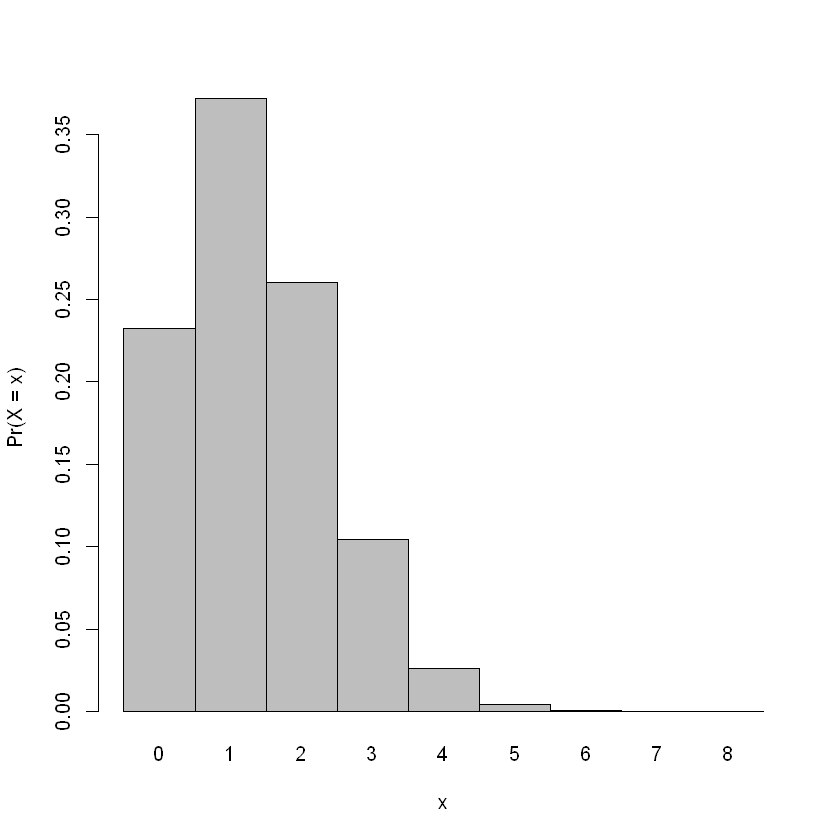

In [ ]:
barplot(X.prob,names.arg=0:8,space=0,xlab="x",ylab="Pr(X = x)")
# names.arg = 0:8：指定 x 轴下方的标签，对应 0 到 8 次成功
# space = 0：柱子之间没有间隔，视觉上更紧凑

In [ ]:
pbinom(q=3,size=8,prob=1/6) # Pr(X ≤ 3) cumulative probability

[1] 0.9693436

| 前缀  | 含义                      | 例子         | 说明                   |
| --- | ----------------------- | ---------- | -------------------- |
| `d` | **density** / PMF 或 PDF | `dbinom()` | $P(X = x)$，概率质量函数    |
| `p` | **probability** / CDF   | `pbinom()` | $P(X \leq x)$，累计概率函数 |
| `q` | **quantile**            | `qbinom()` | 给定概率，反查对应的 x 值       |
| `r` | **random**              | `rbinom()` | 生成二项分布的随机样本          |


In [ ]:
#qbinom provides a quantile value when given a cumulative probability p
qbinom(p=0.95,size=8,prob=1/6)
# 找到最小的x值，使得p（X<=x）>=0.95

[1] 3

In [ ]:
rbinom(n=1,size=8,prob=1/6) #random generation
#0次成功

[1] 0

In [112]:
rbinom(n=1,size=8,prob=1/6)

[1] 2

In [113]:
rbinom(n=3,size=8,prob=1/6)

[1] 2 2 1

##### Poisson Distribution

In [114]:
dpois(x=3,lambda=3.22)

[1] 0.2223249

In [116]:
print(round(dpois(0:10,3.22),3))

 [1] 0.040 0.129 0.207 0.222 0.179 0.115 0.062 0.028 0.011 0.004 0.001


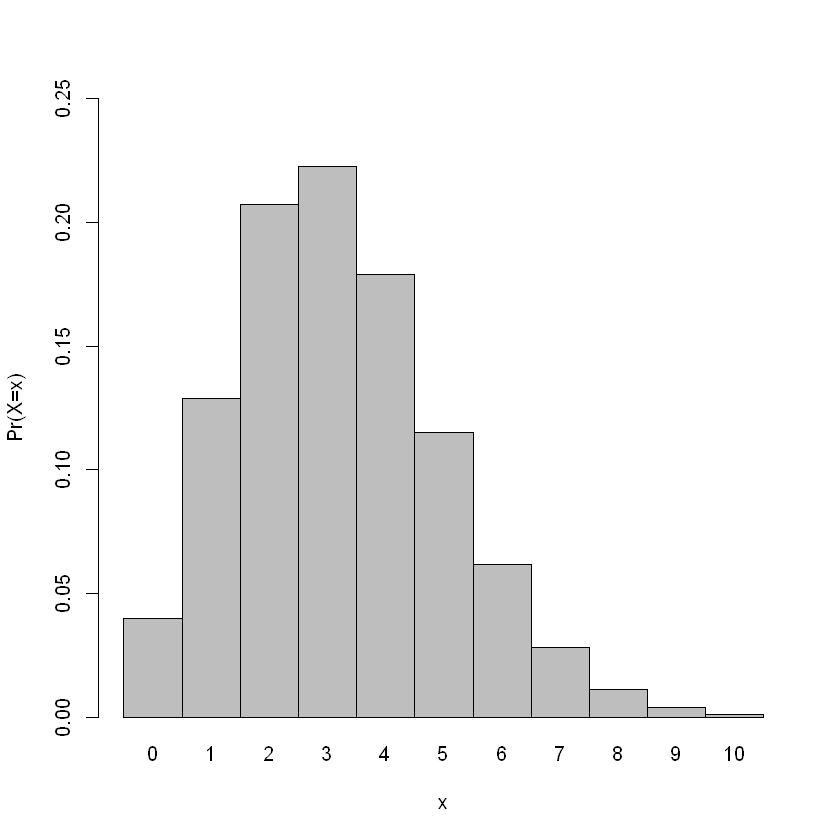

In [117]:
barplot(dpois(x=0:10,lambda=3.22),ylim=c(0,0.25),space=0,
        names.arg=0:10,ylab="Pr(X=x)",xlab="x")

In [118]:
ppois(q=2,lambda=3.22)

[1] 0.3757454

In [120]:
qpois(p=0.9,lambda=3.22)

[1] 6

In [122]:
print(rpois(n=15,lambda=3.22))

 [1] 2 2 4 6 3 2 4 2 5 4 1 5 4 4 5


##### Uniform

$f(x)=\frac{1}{b-a}$ when $a\leq x \leq b$

In [123]:
dunif(x=c(-2,-0.33,0,0.5,1.05,1.2),min=-0.4,max=1.1) #density

[1] 0.0000000 0.6666667 0.6666667 0.6666667 0.6666667 0.0000000

In [125]:
a1 <- -4/10
b1 <- 11/10
punif(-0.21,min=a1,max=b1)

[1] 0.1266667

In [126]:
1-punif(q=0.6,min=a1,max=b1)

[1] 0.3333333

In [127]:
punif(q=0.6,min=a1,max=b1) - punif(q=-0.21,min=a1,max=b1)

[1] 0.54

In [128]:
qunif(p=1-1/3,min=a1,max=b1)

[1] 0.6

In [129]:
print(runif(n=10,min=a1,max=b1))

 [1]  0.55522396  0.72134870  0.04192322  0.18856971 -0.04987428  0.97568496
 [7]  0.89799538  0.18247712  0.50281567  0.69234635


##### Normal

In [130]:
xvals <- seq(-4,4,length=50)
fx <- dnorm(xvals,mean=0,sd=1)
print(fx)

 [1] 0.0001338302 0.0002537388 0.0004684284 0.0008420216 0.0014737603
 [6] 0.0025116210 0.0041677820 0.0067340995 0.0105944324 0.0162292891
[11] 0.0242072211 0.0351571786 0.0497172078 0.0684578227 0.0917831740
[16] 0.1198192782 0.1523049307 0.1885058641 0.2271744074 0.2665738719
[21] 0.3045786052 0.3388479358 0.3670573564 0.3871565916 0.3976152387
[26] 0.3976152387 0.3871565916 0.3670573564 0.3388479358 0.3045786052
[31] 0.2665738719 0.2271744074 0.1885058641 0.1523049307 0.1198192782
[36] 0.0917831740 0.0684578227 0.0497172078 0.0351571786 0.0242072211
[41] 0.0162292891 0.0105944324 0.0067340995 0.0041677820 0.0025116210
[46] 0.0014737603 0.0008420216 0.0004684284 0.0002537388 0.0001338302


In [131]:
pnorm(q=1)-pnorm(q=-1) #mean=0 and sd=1

[1] 0.6826895

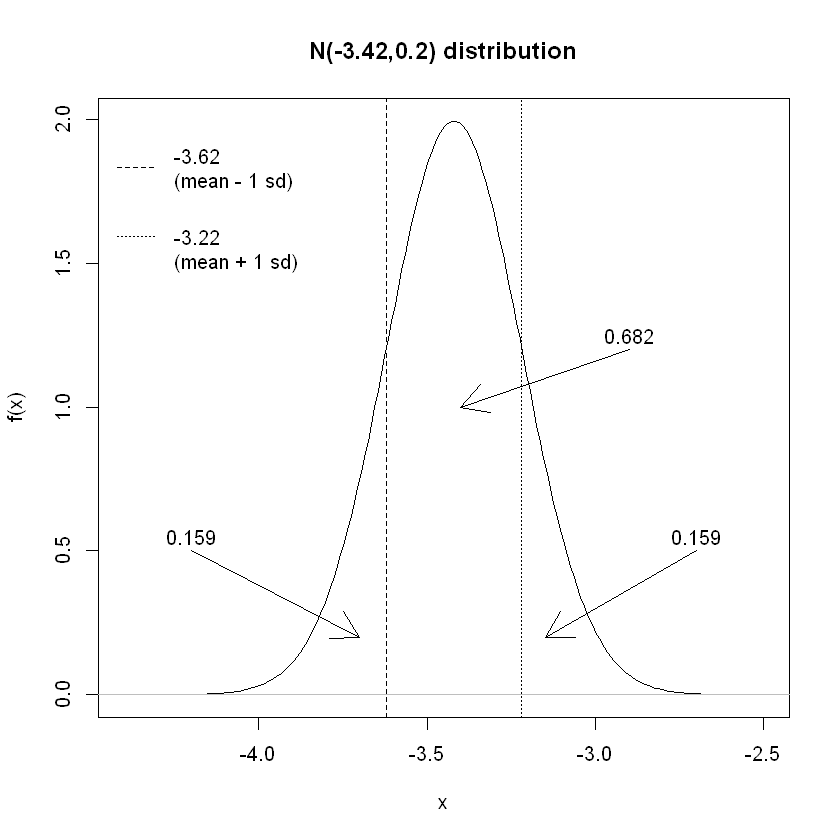

In [134]:
xvals <- seq(-5,-2,length=300)
fx <- dnorm(xvals,mean=mu,sd=sigma)
plot(xvals,fx,type="l",xlim=c(-4.4,-2.5),main="N(-3.42,0.2) distribution",xlab="x",ylab="f(x)")
abline(h=0,col="gray")
abline(v=c(mu.plus.1sig,mu.minus.1sig),lty=3:2)
legend("topleft",legend=c("-3.62\n(mean - 1 sd)","\n-3.22\n(mean + 1 sd)"),lty=2:3,bty="n")
arrows(c(-4.2,-2.7,-2.9),c(0.5,0.5,1.2),c(-3.7,-3.15,-3.4),c(0.2,0.2,1))
text(c(-4.2,-2.7,-2.9),c(0.5,0.5,1.2)+0.05,labels=c("0.159","0.159","0.682"))

In [135]:
qnorm(p=0.159,mean=mu,sd=sigma)

[1] -3.619715

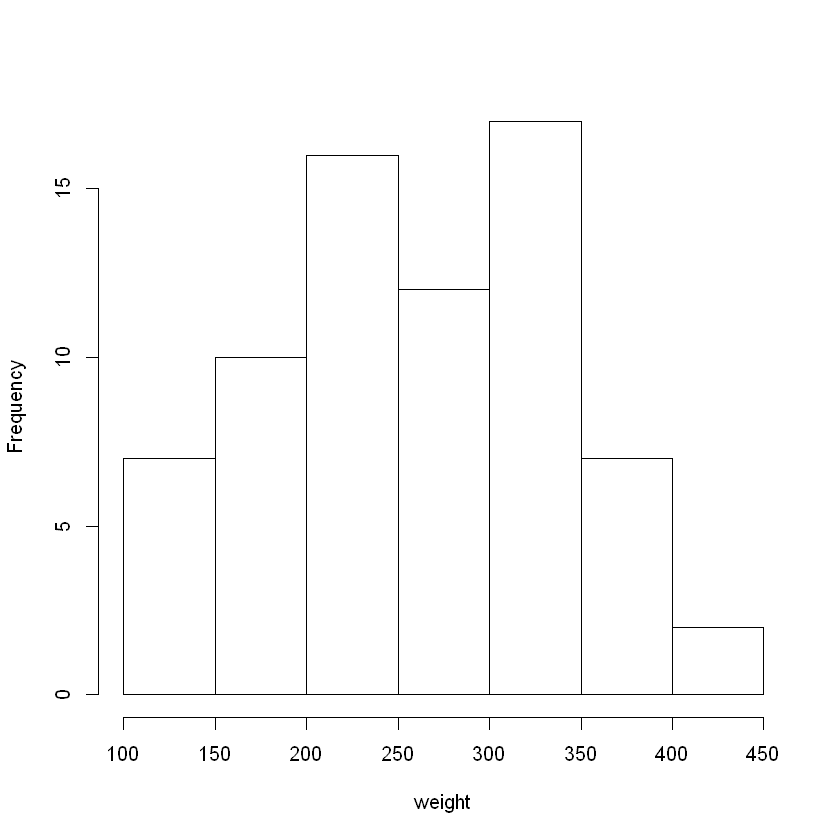

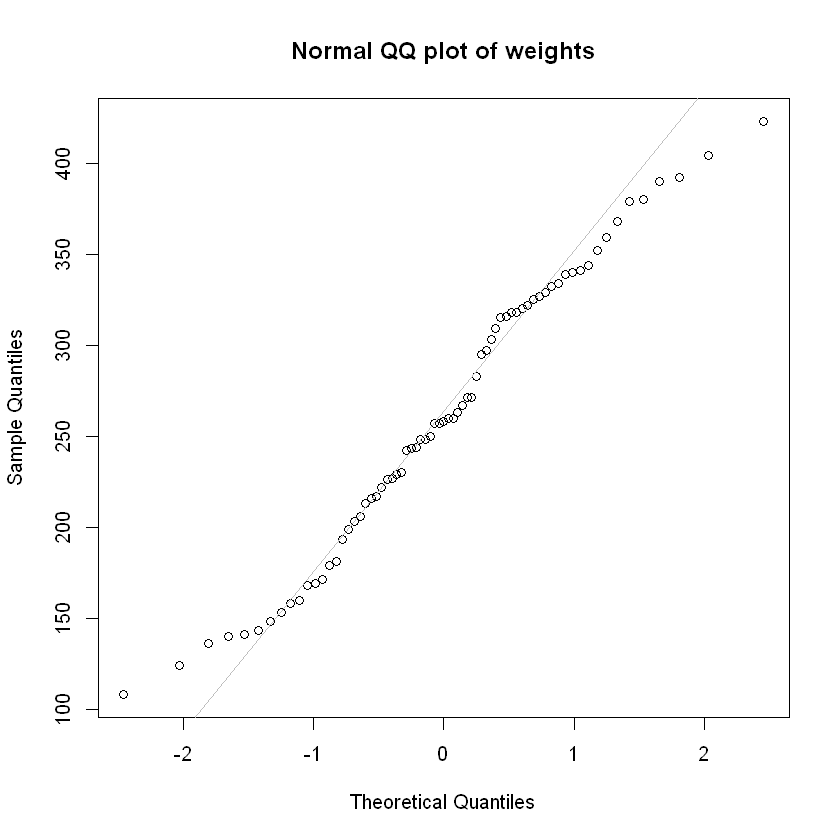

In [136]:
hist(chickwts$weight,main="",xlab="weight")
qqnorm(chickwts$weight,main="Normal QQ plot of weights")
qqline(chickwts$weight,col="gray")

In [137]:
rnorm(n=7,mu,sigma)

[1] -3.475333 -3.396488 -3.593824 -3.176895 -3.711808 -3.149473 -3.365957

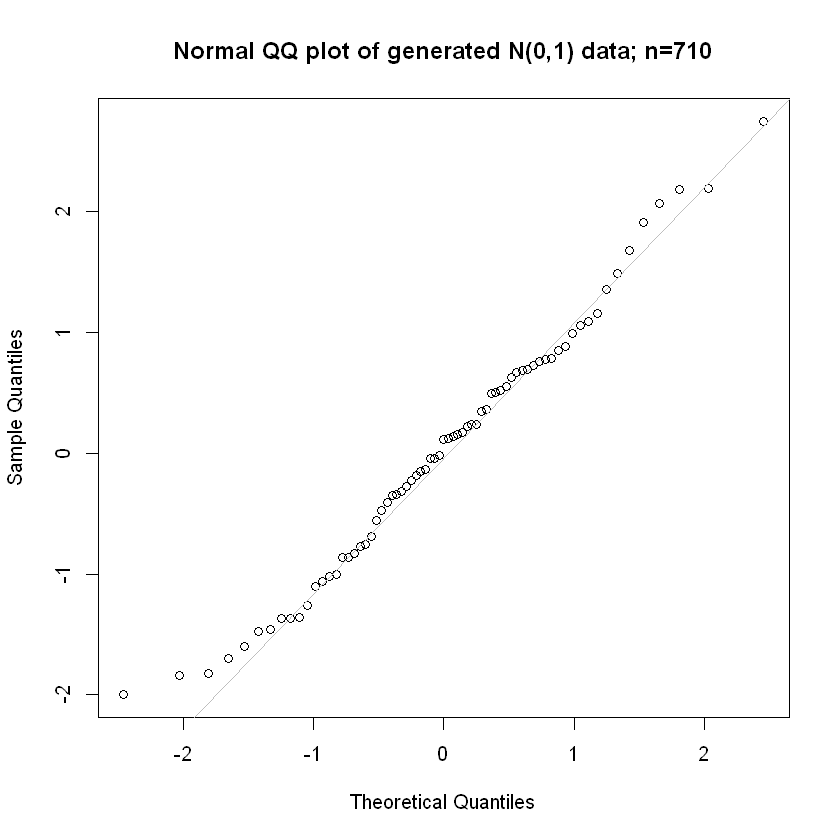

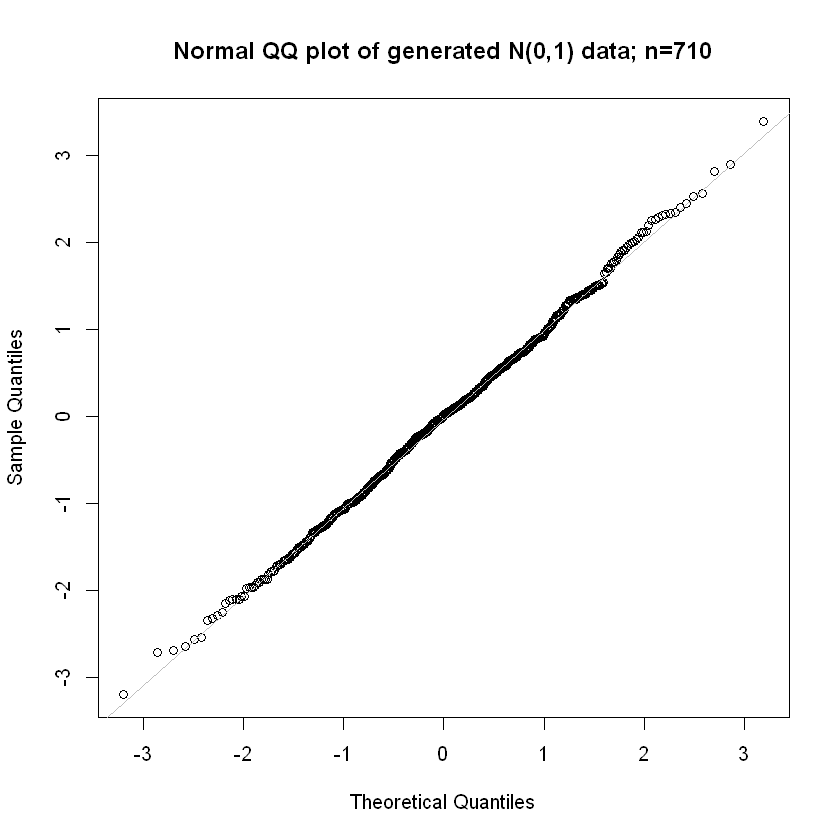

In [138]:
fakedata1 <- rnorm(n=71)
fakedata2 <- rnorm(n=710)
qqnorm(fakedata1,main="Normal QQ plot of generated N(0,1) data; n=710")
qqline(fakedata1,col="gray")
qqnorm(fakedata2,main="Normal QQ plot of generated N(0,1) data; n=710")
qqline(fakedata2,col="gray")

##### Student’s t-distribution 斯图登特t分布


> 对于 t 分布，`dt`、`pt`、`qt` 和 `rt` 函数分别表示 R 语言中用于计算概率密度函数（density）、累积分布函数（左侧概率）、分位数函数（quantile）和随机变量生成（random variate generation）的函数实现。


| 功能              | 函数名称   | 举例          |
| --------------- | ------ | ----------- |
| 密度函数（PDF）       | `dt()` | `dt(x, df)` |
| 累积分布函数（CDF）     | `pt()` | `pt(q, df)` |
| 分位数函数（Quantile） | `qt()` | `qt(p, df)` |
| 随机数生成           | `rt()` | `rt(n, df)` |


In [140]:
qnorm(1-0.05)
qt(1-0.05,df=1)
qt(1-0.05,df=6)
qt(1-0.05,df=20)

[1] 1.644854

[1] 6.313752

[1] 1.94318

[1] 1.724718

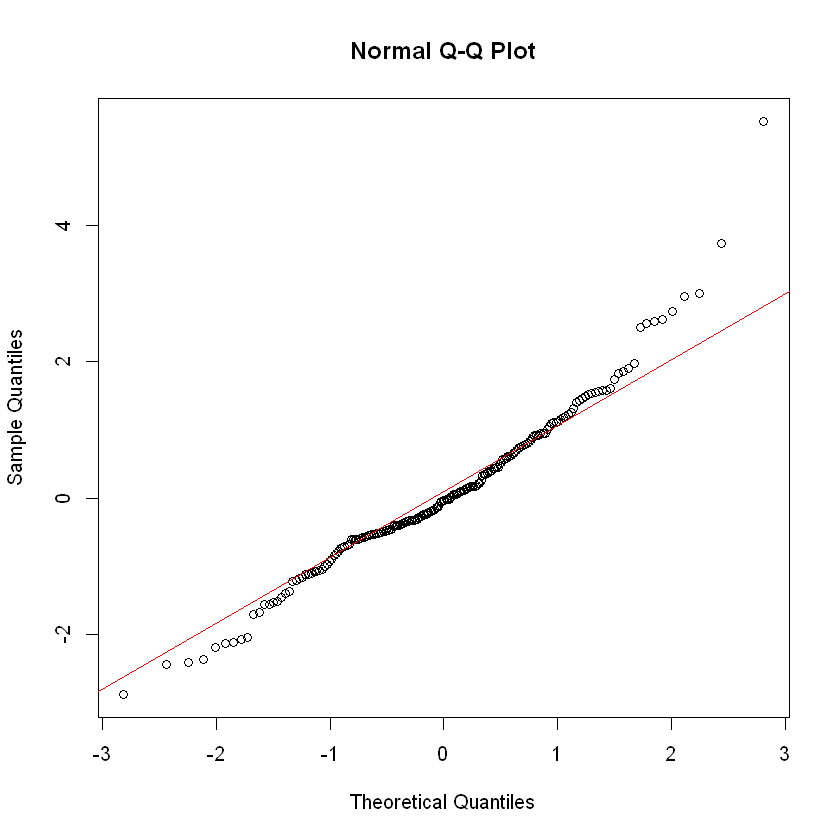

In [1]:
y <- rt(200, df = 5)
qqnorm(y); qqline(y, col = 2)

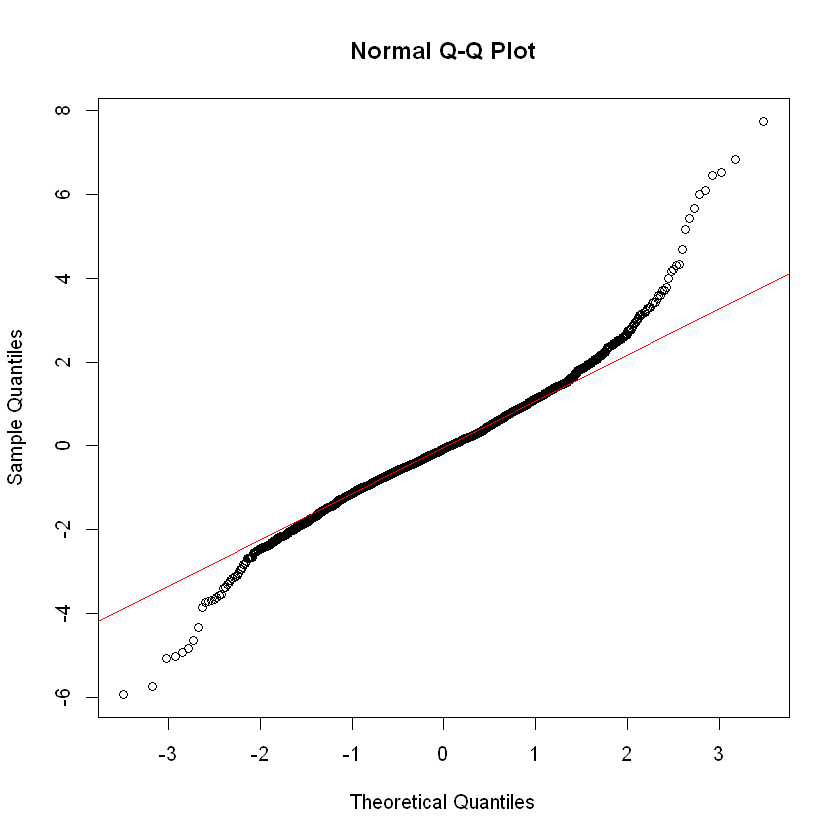

In [6]:
y <- rt(2000, df = 5)
qqnorm(y); qqline(y, col = 2)